# Common Mode and Drift

In [1]:
# from 2f_amp_prop_script
import os
import json
import sqlite3
import numpy as np
from datetime import datetime, timedelta
import time
from concurrent.futures import ProcessPoolExecutor, as_completed
import argparse
import hashlib
import filelock
import re
import sys  # Add missing import for sys
import pandas as pd

from Dpipe import repkg, pipe, timeseries_util as tsu, startup
from Dpipe import survey_span_gen as spg
from Dpipe.mss_util import extract_templates_from_span
from Dpipe.database_utils import get_database_spans
from Dpipe import mss_util as util
import vivian_fit as vfit

verbose=True

def log(msg):
    if verbose:
        print(msg, flush=True)

dpipe_path = os.getenv('DPIPE_PREFIX')

config = startup.DpipeConfig(os.path.join(dpipe_path, 'Dpipe/parameter_files/test-vt.yml'))
print(f"\nHWP config: recv={config.recv}, timeline={config.timeline}")
print(f"  UIDs: {config.uids}")


HWP config: recv=w1_band, timeline={'era4': 'w1_full'}
  UIDs: {'era4': [0, 1, 2, 3, 4, 6, 7, 8, 9, 10, 11, 12, 13, 15, 16, 17, 18, 19, 20, 22, 23, 26, 29, 30, 32, 33, 44, 45, 47, 48, 49, 67, 68, 70, 71, 72, 74, 75, 76, 77, 79, 80, 81, 82, 84, 85, 86, 87, 89, 90, 91, 92, 94, 95, 96, 97, 98, 102, 103, 106, 110, 113, 114, 116, 119, 120, 121, 123, 124, 126, 127, 128, 129, 130, 132, 133, 135, 140, 141, 145, 148, 154, 156, 158, 159, 160, 161, 162, 163, 164, 167, 168, 169, 170, 172, 173, 174, 177, 180, 182, 183, 204, 205, 206, 208, 209, 211, 212, 214, 215, 216, 217, 220, 223, 224, 225, 226, 228, 229, 230, 231, 233, 235, 236, 239, 242, 243, 248, 253, 255, 257, 261, 262, 263, 264, 265, 266, 267, 268, 270, 272, 277, 280, 281, 282, 287, 289, 293, 294, 295, 301, 302, 303, 304, 305, 306, 309, 313, 314, 316, 317, 319, 320, 321, 323, 324, 326, 327, 330, 331, 332, 334, 336, 337, 338, 339, 340, 341, 343, 344, 346, 348, 349, 350, 351, 353, 355, 356, 358, 359, 360, 361, 362, 363, 365, 367, 368, 369, 37

In [2]:
startup.DpipeConfig.load_timeline(config)
timeline = config.loaded_timeline

In [3]:
print(config.loaded_timeline)

{'era4-survey_start': [datetime.datetime(2024, 7, 1, 0, 0), True], 'era4-exclusion_0_start': [datetime.datetime(2024, 7, 10, 12, 0), False], 'era4-exclusion_0_end': [datetime.datetime(2024, 7, 17, 14, 0), True], 'era4-survey_end': [datetime.datetime(2025, 8, 30, 14, 0), False]}


In [4]:
survey_start = pd.Timestamp(timeline['era4-survey_start'][0])
survey_end = pd.Timestamp(timeline['era4-survey_end'][0])
exclusion_start = pd.Timestamp(timeline['era4-exclusion_0_start'][0])
exclusion_end = pd.Timestamp(timeline['era4-exclusion_0_end'][0])

In [5]:
spans=[]
exclusions = [(exclusion_start, exclusion_end)]
day = survey_start.normalize()
while day <= survey_end:
    start = day
    end = day + pd.Timedelta(hours=8)

    # Don't go outside survey range
    start = max(start, survey_start)
    end = min(end, survey_end)

    # Check for exclusions
    for excl_start, excl_end in exclusions:
        # If exclusion overlaps this span
        if start < excl_end and end > excl_start:
            # Remove the overlapping portion
            if excl_start <= start and excl_end >= end:
                # Entire span is excluded
                start = None
                break

            elif excl_start <= start:
                start = excl_end

            elif excl_end >= end:
                end = excl_start

            else:
                # Exclusion is in the middle -> split into two spans
                spans.append((start, excl_start))
                start = excl_end

    if start is not None and start < end:
        spans.append((start, end))

    day += pd.Timedelta(days=1)

spans = pd.DataFrame(spans, columns=["start", "end"])

In [6]:
print(spans[spans["start"] == pd.Timestamp("2025-04-04")])

         start                 end
270 2025-04-04 2025-04-04 08:00:00


In [7]:
spans_winter = spans[(spans["start"] >= pd.Timestamp("2025-04-07")) & (spans["start"] <= pd.Timestamp("2025-06-14"))]
print(len(spans_winter))

69


### RUN WILL TAKE 10 HOURS

In [ ]:
all_common_modes = []
first_write = True
print("starting")
with open("output.txt", "w") as f:
    for i in range(0, len(spans_winter), 2):
    
        times = spans_winter.iloc[i]
        
        start = times.start.to_pydatetime()
        end = times.end.to_pydatetime()
    
        span_id = i + 273
        print("starting span %2.1f" % (span_id), file=f, flush=True)
    
        span = repkg.Span(start, end, config)
        
        try:
            span.load_tod(new_cache=False)
        except FileNotFoundError as e:
            print(f"  WARNING: missing data for span {span_id}: {e}", file=f, flush=True)
            continue
        if span.kill_build:
            print("  WARNING: Span marked for kill (idle or aborted scan)", file=f, flush=True)
            continue
    
        try:
            span.init_cuts(config=config)
            log("Cuts initialized; setting scan speed")
            span.set_scan_speed(span)
            log("Scan speed set; applying cut_and_fix")
            pipe.cut_and_fix(span, config, verbose=True)
            log("Cuts applied; calibrating TOD")
            tsu.cal_tod(span) ## 56lp is set to pwv calibration
            log("Calibration done; running single_det")
            span.single_det() ## divides each detector by relative efficiency
            log("single_det complete;")

            filtered_span_data = vfit.filter_span_data(span, freq_mult=2, verbose=True)
    
            raw_template =vfit.extract_templates_from_span(span, filtered_span_data, binning=False, bin_med=False, n=10, verbose=True)
        except Exception as e:
            print(f"  ERROR processing span {span_id}",
                  file=f, flush=True)
            continue
    
        if len(raw_template) > 0 :
            rows = []
            for timestamp, detectors in raw_template.items():
                for det_id, values in detectors.items():
                    rows.append({
                        "timestamp": float(timestamp),   # or pd.to_datetime(float(timestamp), unit="s")
                        "det_uid": det_id,
                        "amplitude": values["amplitude"],
                        "scaling_factor": values["scaling_factor"],
                        "quality": values["quality"],
                        "A": values['A'],
                        "B": values['B'],
                        "C": values['C'],
                        "segment_id": values['segment_id']
                    })
            if len(rows) > 0 :      
                template = pd.DataFrame(rows)
            
                common_mode = template.groupby('segment_id')[['amplitude', 'A', 'B', 'C']].mean()
            
                common_mode["span_id"] = span_id
    
                # Write this span immediately
                common_mode.to_csv(
                    "common_mode_winter_second.csv",
                    mode="w" if first_write else "a",
                    header=first_write,
                    index=False
                )
    
                first_write = False
    
                print(
                    "span %2.1f done and saved" % span_id,
                    file=f,
                    flush=True
                )
        else:
            print("span %2.1f empty" % (span_id), file=f, flush=True)
    print("done", file=f, flush=True)

    # common_modes = pd.concat(all_common_modes).reset_index()
    # common_modes.to_csv("common_mode_tenth_v2.csv", index=False)
    # print("saved", file=f, flush=True)

starting
Cuts initialized; setting scan speed
Scan speed set; applying cut_and_fix
loading initial cuts


/home/viviantao1/.local_class/lib/python3.11/site-packages/Dpipe/cuts.py:571: RuntimeWarning: invalid value encountered in divide
  ratio[np.abs(np.ptp(y_in, axis=-1) / p[:, 0]) < 1e-12] = np.nan


repairing relocks
finding flux jump density
repairing flux jumps
finding missed flux jumps
filling cuts
Cuts applied; calibrating TOD
Calibration done; running single_det
single_det complete;
Extracting templates from 490 segments...
Cuts initialized; setting scan speed
Scan speed set; applying cut_and_fix
loading initial cuts
repairing relocks
finding flux jump density
repairing flux jumps
finding missed flux jumps
filling cuts
Cuts applied; calibrating TOD
Calibration done; running single_det
single_det complete;
Extracting templates from 490 segments...
Cuts initialized; setting scan speed
Scan speed set; applying cut_and_fix
loading initial cuts
repairing relocks
finding flux jump density
repairing flux jumps
finding missed flux jumps
filling cuts
Cuts applied; calibrating TOD
Calibration done; running single_det
single_det complete;
Extracting templates from 490 segments...
Cuts initialized; setting scan speed
Scan speed set; applying cut_and_fix
loading initial cuts
repairing rel

[07:40:17] CRITICAL [dpipe.repkg._load_det_data:1098] read_data=True, but no detector data was found in 2025-05-09-00-00-00. zeroing dataset.
[07:40:18] CRITICAL [dpipe.repkg._load_det_data:1098] read_data=True, but no detector data was found in 2025-05-09-00-10-00. zeroing dataset.
[07:40:18] CRITICAL [dpipe.repkg._load_det_data:1098] read_data=True, but no detector data was found in 2025-05-09-00-20-00. zeroing dataset.
[07:40:19] CRITICAL [dpipe.repkg._load_det_data:1098] read_data=True, but no detector data was found in 2025-05-09-00-30-00. zeroing dataset.
[07:40:19] CRITICAL [dpipe.repkg._load_det_data:1098] read_data=True, but no detector data was found in 2025-05-09-00-40-00. zeroing dataset.
[07:40:20] CRITICAL [dpipe.repkg._load_det_data:1098] read_data=True, but no detector data was found in 2025-05-09-00-50-00. zeroing dataset.
[07:40:20] CRITICAL [dpipe.repkg._load_det_data:1098] read_data=True, but no detector data was found in 2025-05-09-01-00-00. zeroing dataset.
[07:40

Cuts initialized; setting scan speed
Scan speed set; applying cut_and_fix
loading initial cuts


/home/viviantao1/.local_class/lib/python3.11/site-packages/Dpipe/cuts.py:571: RuntimeWarning: invalid value encountered in divide
  ratio[np.abs(np.ptp(y_in, axis=-1) / p[:, 0]) < 1e-12] = np.nan


repairing relocks
finding flux jump density
repairing flux jumps
finding missed flux jumps
filling cuts
Cuts applied; calibrating TOD
Calibration done; running single_det
single_det complete;
Extracting templates from 490 segments...
Cuts initialized; setting scan speed
Scan speed set; applying cut_and_fix
loading initial cuts
repairing relocks
finding flux jump density
repairing flux jumps
finding missed flux jumps
filling cuts
Cuts applied; calibrating TOD
Calibration done; running single_det
single_det complete;
Extracting templates from 490 segments...
Cuts initialized; setting scan speed
Scan speed set; applying cut_and_fix
loading initial cuts
repairing relocks
finding flux jump density
repairing flux jumps
finding missed flux jumps
filling cuts
Cuts applied; calibrating TOD
Calibration done; running single_det
single_det complete;
Extracting templates from 490 segments...


### housekeeping data

In [6]:
house_streams = np.load("/data/users/class/mapmaking_in/dtod/w1_band/57lp/2025-04-03-22-10-00_78/house.npz")

In [7]:
print(house_streams.keys())

KeysView(NpzFile '/data/users/class/mapmaking_in/dtod/w1_band/57lp/2025-04-03-22-10-00_78/house.npz' with keys: weather_winddir, weather_windspeed)


In [9]:
wind_dir = house_streams['weather_winddir']
windspeed = house_streams['weather_windspeed']

In [ ]:
i = 30
times = spans.iloc[i]

start = times.start.to_pydatetime()
end = times.end.to_pydatetime()

span_id = i

span = repkg.Span(start, end, config)

span.load_tod(new_cache=False)

In [13]:
house = span.get_house(['weather', 'airtemp'])

In [15]:
print(len(house))

5913000


In [16]:
house = span.get_async_data('weather', 'windspeed')

In [18]:
print(len(house[1]))

14700


In [23]:
print(house[1])

[5.70499992 5.32200003 4.94000006 ... 8.         7.6170001  7.23500013]


In [8]:
def split_house(span, keys, n):
    slices = span.get_segments(unit='dpkg')
    if n != 1:
        small_slices = []
        for dpkg in slices:
            edges = np.linspace(dpkg.start, dpkg.stop, n + 1).astype(int)
            for i in range(n):
                small_slices.append(slice(edges[i], edges[i + 1]))
        slices = small_slices

    results = {}
    for key in keys:
        house = span.get_house(key)
        name = key[1] if isinstance(key, (list, tuple)) else key
        results[name] = {seg_n: np.mean(house[seg]) for seg_n, seg in enumerate(slices)}
    return results

In [9]:
all_housekeeping = []
first_write = True
print("starting")
keys = [['weather', 'rh'],
        ['weather', 'solar'],
        ['weather', 'airtemp'],
        ['weather', 'winddir'],
        ['weather', 'windspeed']]
with open("output.txt", "w") as f:
    for i in range(0, len(spans), 10):
    
        times = spans.iloc[i]
        
        start = times.start.to_pydatetime()
        end = times.end.to_pydatetime()
    
        span_id = i
        print("starting span %2.1f" % (span_id), file=f, flush=True)
    
        span = repkg.Span(start, end, config)
        
        try:
            span.load_tod(new_cache=False)
        except FileNotFoundError as e:
            print(f"  WARNING: missing data for span {span_id}: {e}", file=f, flush=True)
            continue
        if span.kill_build:
            print("  WARNING: Span marked for kill (idle or aborted scan)", file=f, flush=True)
            continue
    
        try:
            house = split_house(span, keys, n=10)
        except Exception as e:
            print(f"  ERROR extracting housekeeping data for span {span_id}: {e}",
                  file=f, flush=True)
            continue
    
        # house is {field: {segment_id: mean}}, e.g. house['winddir'][3]
        if len(house) > 0 and any(len(v) > 0 for v in house.values()):
            df = pd.DataFrame(house)                     # rows = segments, columns = fields
            df.index.name = "segment_id"
            df = df.reset_index()
            df.insert(0, "span_id", span_id)

            # Write this span immediately
            df.to_csv(
                "housekeeping_tenth.csv",
                mode="w" if first_write else "a",
                header=first_write,
                index=False
            )
            first_write = False

            print("span %2.1f housekeeping done and saved" % span_id, file=f, flush=True)
        else:
            print("span %2.1f housekeeping empty" % span_id, file=f, flush=True)

    print("done", file=f, flush=True)

starting


[19:23:10] CRITICAL [dpipe.repkg._load_det_data:1098] read_data=True, but no detector data was found in 2025-08-22-00-00-00. zeroing dataset.
[19:23:10] CRITICAL [dpipe.repkg._load_det_data:1098] read_data=True, but no detector data was found in 2025-08-22-00-10-00. zeroing dataset.
[19:23:10] CRITICAL [dpipe.repkg._load_det_data:1098] read_data=True, but no detector data was found in 2025-08-22-00-20-00. zeroing dataset.
[19:23:10] CRITICAL [dpipe.repkg._load_det_data:1098] read_data=True, but no detector data was found in 2025-08-22-00-30-00. zeroing dataset.
[19:23:11] CRITICAL [dpipe.repkg._load_det_data:1098] read_data=True, but no detector data was found in 2025-08-22-00-40-00. zeroing dataset.
[19:23:11] CRITICAL [dpipe.repkg._load_det_data:1098] read_data=True, but no detector data was found in 2025-08-22-00-50-00. zeroing dataset.
[19:23:11] CRITICAL [dpipe.repkg._load_det_data:1098] read_data=True, but no detector data was found in 2025-08-22-01-00-00. zeroing dataset.
[19:23

### plots

In [10]:
import matplotlib.pyplot as plt
%matplotlib inline

In [12]:
common_modes_tenth = pd.read_csv("common_mode_tenth.csv")
common_modes_no_relock = pd.read_csv("common_mode_no_relock_fifth.csv")
common_modes_winter = pd.read_csv("common_mode_winter_second.csv")

In [11]:
repeats = np.arange(277,347,10)
print(repeats)

[277 287 297 307 317 327 337]


In [12]:
full_common_modes = pd.concat(
    [common_modes_tenth, common_modes_no_relock, common_modes_winter[~common_modes_winter["span_id"].isin(repeats)]],
    ignore_index=True
)
full_common_modes.head()

,amplitude,A,B,C,span_id
0,0.016965,0.002403,0.001092,8.524096e-07,20
1,0.016955,0.002394,0.001103,-4.277959e-08,20
2,0.016996,0.002405,0.001105,4.042349e-08,20
3,0.017003,0.002394,0.001101,-3.646937e-08,20
4,0.016977,0.002391,0.001093,8.303462e-09,20


In [13]:
full_common_modes["segment_id"] = full_common_modes.groupby("span_id").cumcount()
full_common_modes = full_common_modes.sort_values(
    ["span_id", "segment_id"]
).reset_index(drop=True)
full_common_modes

,amplitude,A,B,C,span_id,segment_id
0,0.016965,0.002403,0.001092,8.524096e-07,20,0
1,0.016955,0.002394,0.001103,-4.277959e-08,20,1
2,0.016996,0.002405,0.001105,4.042349e-08,20,2
3,0.017003,0.002394,0.001101,-3.646937e-08,20,3
4,0.016977,0.002391,0.001093,8.303462e-09,20,4
...,...,...,...,...,...,...
40175,0.013916,0.003341,0.001962,7.592364e-09,417,485
40176,0.013973,0.003330,0.001956,-1.539310e-08,417,486
40177,0.013970,0.003334,0.001958,-2.894696e-08,417,487
40178,0.013917,0.003346,0.001955,1.081788e-08,417,488


In [14]:
full_common_modes.to_csv("full_common_mode_set.csv", index=False)

In [11]:
full_common_modes = pd.read_csv("full_common_mode_set.csv")

In [12]:
full_common_modes.head()

,amplitude,A,B,C,span_id,segment_id
0,0.016965,0.002403,0.001092,8.524096e-07,20,0
1,0.016955,0.002394,0.001103,-4.277959e-08,20,1
2,0.016996,0.002405,0.001105,4.042349e-08,20,2
3,0.017003,0.002394,0.001101,-3.646937e-08,20,3
4,0.016977,0.002391,0.001093,8.303462e-09,20,4


In [13]:
span_ids = full_common_modes['span_id'].unique()
print(span_ids)

[ 20  30  40  50  60  70 100 110 120 130 140 150 160 170 180 187 190 197
 200 202 207 210 270 272 273 275 277 279 280 281 282 283 285 287 291 292
 293 295 297 299 300 301 302 303 305 307 309 310 311 312 313 315 317 319
 320 321 322 323 325 327 329 330 331 332 333 335 337 339 350 352 367 370
 372 377 380 382 387 400 402 410 412 417]


In [14]:
span_time = pd.date_range(
    start="00:00",
    end="08:00",
    periods=490
)
print(span_time)

DatetimeIndex([          '2026-10-06 00:00:00',
               '2026-10-06 00:00:58.895705521',
               '2026-10-06 00:01:57.791411042',
               '2026-10-06 00:02:56.687116564',
               '2026-10-06 00:03:55.582822085',
               '2026-10-06 00:04:54.478527607',
               '2026-10-06 00:05:53.374233128',
               '2026-10-06 00:06:52.269938650',
               '2026-10-06 00:07:51.165644171',
               '2026-10-06 00:08:50.061349693',
               ...
               '2026-10-06 07:51:09.938650306',
               '2026-10-06 07:52:08.834355828',
               '2026-10-06 07:53:07.730061349',
               '2026-10-06 07:54:06.625766871',
               '2026-10-06 07:55:05.521472392',
               '2026-10-06 07:56:04.417177914',
               '2026-10-06 07:57:03.312883435',
               '2026-10-06 07:58:02.208588957',
               '2026-10-06 07:59:01.104294478',
                         '2026-10-06 08:00:00'],
              dtype=

In [30]:
windspeeds = pd.read_csv("windspeed_tenth.csv")
winddirs = pd.read_csv("winddir_tenth.csv")

In [15]:
housekeeping = pd.read_csv("housekeeping_tenth.csv")

In [16]:
housekeeping.head()

,span_id,segment_id,rh,solar,airtemp,winddir,windspeed
0,20,0,11.097991,0.087555,-6.221716,267.859907,0.759442
1,20,1,11.101609,0.169789,-6.431141,267.848877,0.246486
2,20,2,11.143694,0.098987,-7.039895,267.870842,0.000010
3,20,3,11.226522,0.032571,-6.366689,267.850839,0.000010
4,20,4,11.259868,0.073298,-6.857930,267.851398,0.000010


### Temperature plots

In [18]:
import matplotlib.dates as mdates

Text(0.5, 0, 'Time')

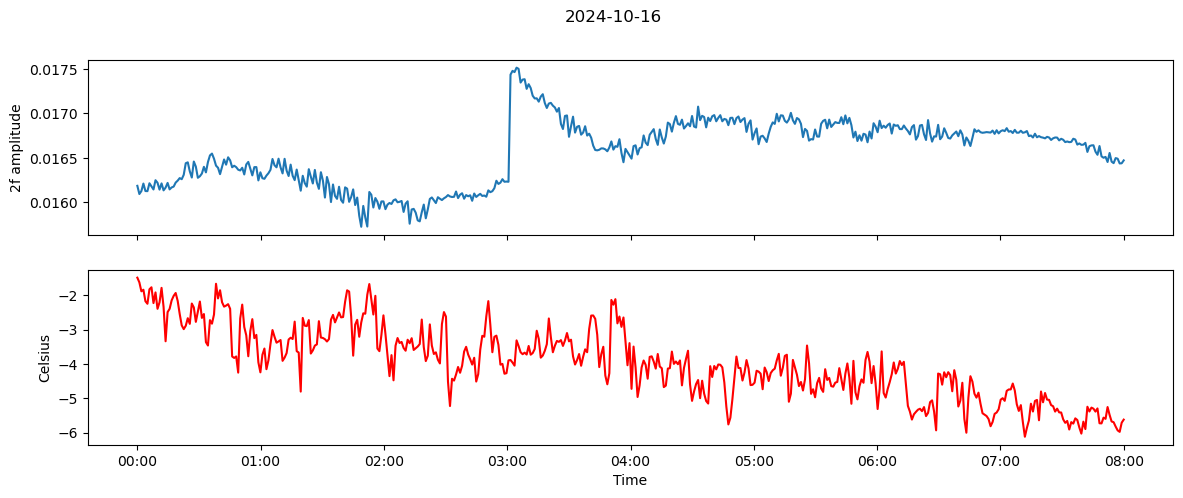

In [20]:
n = 100
amp_2f = full_common_modes[full_common_modes['span_id'] == n]
house = housekeeping[housekeeping['span_id'] == n]
fig, ax = plt.subplots(2,1, figsize=(14, 5), sharex=True)
plt.suptitle(spans.iloc[n]["start"].date().strftime("%Y-%m-%d"))
ax[0].plot(span_time, amp_2f['amplitude'])
ax[0].set_ylabel("2f amplitude")

ax[1].plot(span_time, house['airtemp'], color='red')
ax[1].set_ylabel("Celsius")

plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
plt.xlabel("Time")

Text(0.5, 0, 'Time')

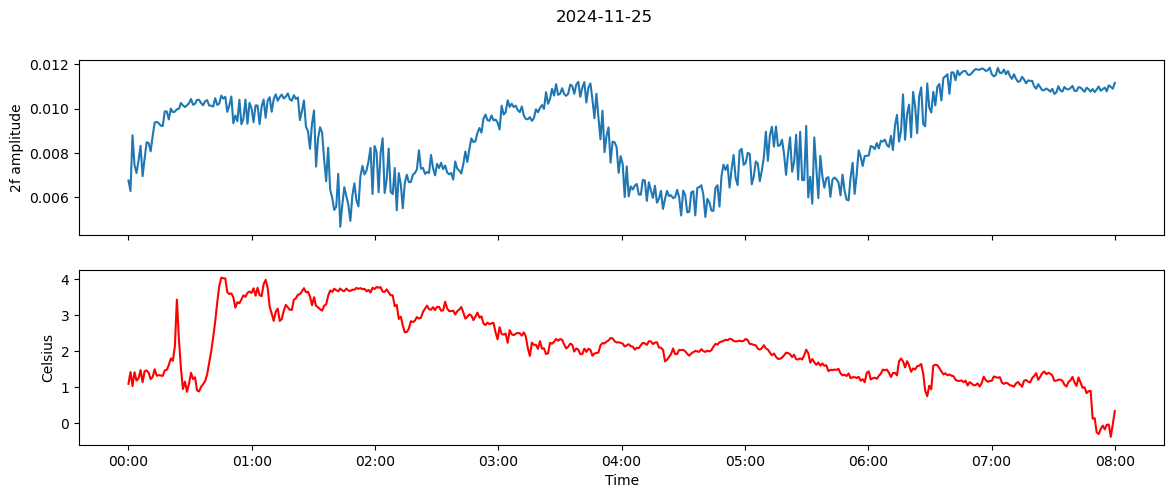

In [21]:
n = 140
amp_2f = full_common_modes[full_common_modes['span_id'] == n]
house = housekeeping[housekeeping['span_id'] == n]
fig, ax = plt.subplots(2,1, figsize=(14, 5), sharex=True)
plt.suptitle(spans.iloc[n]["start"].date().strftime("%Y-%m-%d"))
ax[0].plot(span_time, amp_2f['amplitude'])
ax[0].set_ylabel("2f amplitude")

ax[1].plot(span_time, house['airtemp'], color='red')
ax[1].set_ylabel("Celsius")

plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
plt.xlabel("Time")

In [22]:
full_weather_df = (
    full_common_modes
    .merge(housekeeping, on=["span_id", "segment_id"], how="inner")
)

In [23]:
full_weather_df.head()

,amplitude,A,B,C,span_id,segment_id,rh,solar,airtemp,winddir,windspeed
0,0.016965,0.002403,0.001092,8.524096e-07,20,0,11.097991,0.087555,-6.221716,267.859907,0.759442
1,0.016955,0.002394,0.001103,-4.277959e-08,20,1,11.101609,0.169789,-6.431141,267.848877,0.246486
2,0.016996,0.002405,0.001105,4.042349e-08,20,2,11.143694,0.098987,-7.039895,267.870842,0.000010
3,0.017003,0.002394,0.001101,-3.646937e-08,20,3,11.226522,0.032571,-6.366689,267.850839,0.000010
4,0.016977,0.002391,0.001093,8.303462e-09,20,4,11.259868,0.073298,-6.857930,267.851398,0.000010


(0.0, 0.022)

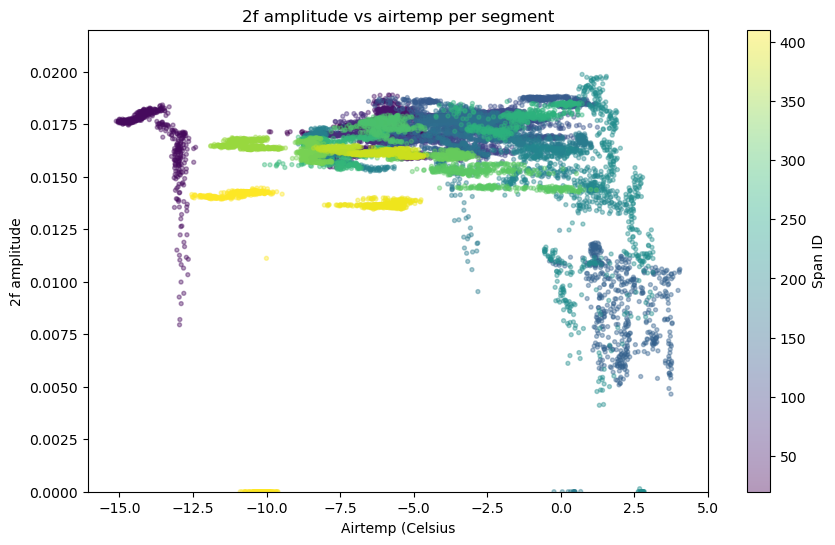

In [26]:
plt.figure(figsize=(10, 6))
plt.scatter(
    full_weather_df["airtemp"],
    full_weather_df["amplitude"],
    c=full_weather_df["span_id"],
    alpha=0.4,
    s=8
)
plt.xlabel("Airtemp (Celsius")
plt.ylabel("2f amplitude")
plt.title("2f amplitude vs airtemp per segment")
plt.colorbar(label="Span ID")
plt.ylim(0,0.022)

### weather per span plots

In [32]:
amp_2f = full_common_modes[full_common_modes['span_id'] == 270]
windspeed = windspeeds[windspeeds['span_id'] == 270]
winddir = winddirs[winddirs['span_id']==270]

Text(0.5, 0, 'Time')

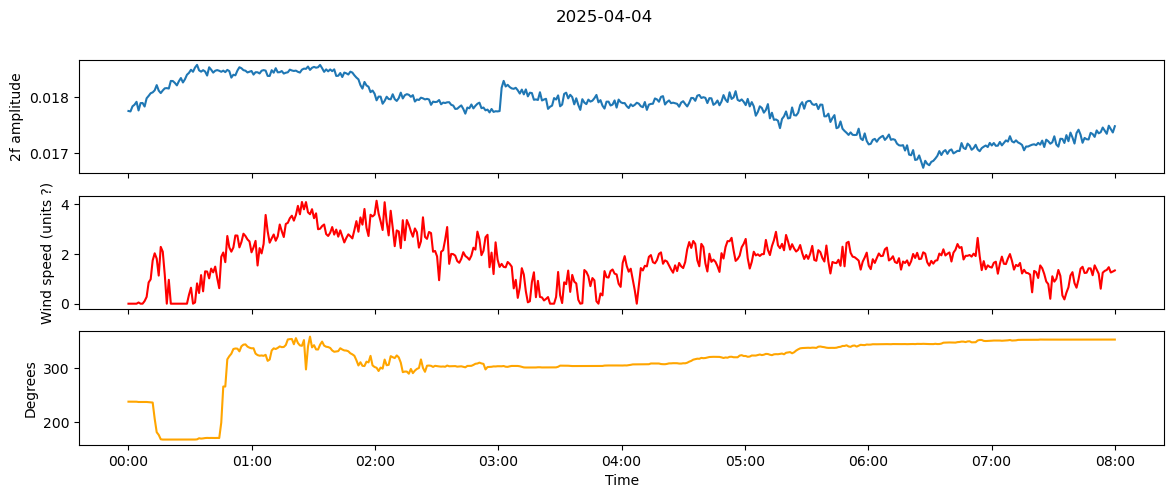

In [39]:
import matplotlib.dates as mdates
fig, ax = plt.subplots(3,1, figsize=(14, 5), sharex=True)
plt.suptitle(spans.iloc[270]["start"].date().strftime("%Y-%m-%d"))
ax[0].plot(span_time, amp_2f['amplitude'])
ax[0].set_ylabel("2f amplitude")
# ax[0].set_title("Span 2f amplitude")

ax[1].plot(span_time, windspeed['windspeed'], color='red')
ax[1].set_ylabel("Wind speed (units ?)")

ax[2].plot(span_time, winddir['winddir'], color='orange')
ax[2].set_ylabel("Degrees")
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
plt.xlabel("Time")
#plt.ylim(0,0.03)

Text(0.5, 0, 'Time')

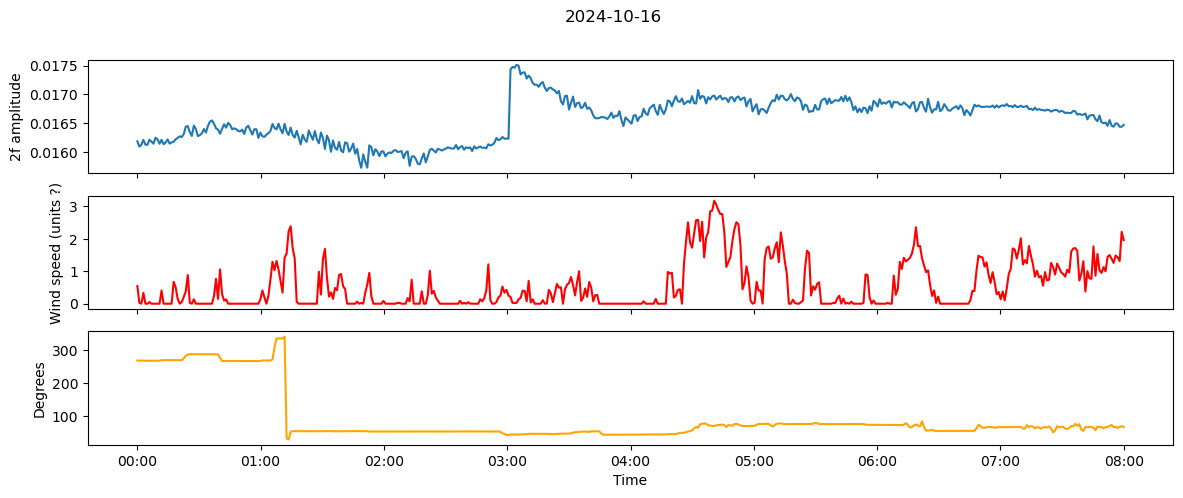

In [40]:
n = 100
amp_2f = full_common_modes[full_common_modes['span_id'] == n]
windspeed = windspeeds[windspeeds['span_id'] == n]
winddir = winddirs[winddirs['span_id']==n]
fig, ax = plt.subplots(3,1, figsize=(14, 5), sharex=True)
plt.suptitle(spans.iloc[n]["start"].date().strftime("%Y-%m-%d"))
ax[0].plot(span_time, amp_2f['amplitude'])
ax[0].set_ylabel("2f amplitude")

ax[1].plot(span_time, windspeed['windspeed'], color='red')
ax[1].set_ylabel("Wind speed (units ?)")

ax[2].plot(span_time, winddir['winddir'], color='orange')
ax[2].set_ylabel("Degrees")
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
plt.xlabel("Time")

Text(0.5, 0, 'Time')

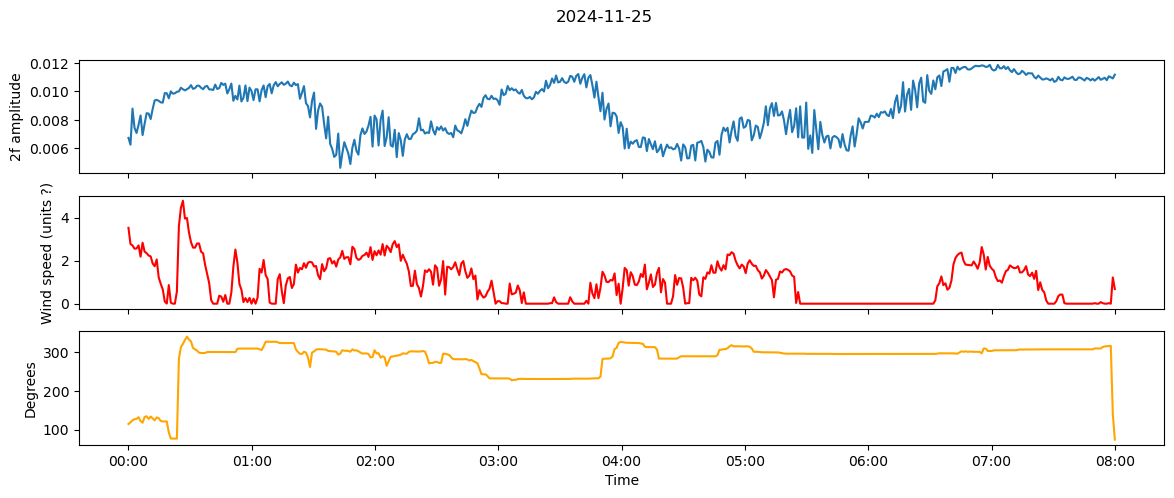

In [41]:
n = 140
amp_2f = full_common_modes[full_common_modes['span_id'] == n]
windspeed = windspeeds[windspeeds['span_id'] == n]
winddir = winddirs[winddirs['span_id']==n]
fig, ax = plt.subplots(3,1, figsize=(14, 5), sharex=True)
plt.suptitle(spans.iloc[n]["start"].date().strftime("%Y-%m-%d"))
ax[0].plot(span_time, amp_2f['amplitude'])
ax[0].set_ylabel("2f amplitude")

ax[1].plot(span_time, windspeed['windspeed'], color='red')
ax[1].set_ylabel("Wind speed (units ?)")

ax[2].plot(span_time, winddir['winddir'], color='orange')
ax[2].set_ylabel("Degrees")
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
plt.xlabel("Time")

### dataframe merge

In [42]:
weather_df = (
    full_common_modes
    .merge(winddirs, on=["span_id", "segment_id"], how="inner")
    .merge(windspeeds, on=["span_id", "segment_id"], how="inner")
)

In [43]:
weather_df.head()

,amplitude,A,B,C,span_id,segment_id,winddir,windspeed
0,0.016965,0.002403,0.001092,8.524096e-07,20,0,267.859907,0.759442
1,0.016955,0.002394,0.001103,-4.277959e-08,20,1,267.848877,0.246486
2,0.016996,0.002405,0.001105,4.042349e-08,20,2,267.870842,0.000010
3,0.017003,0.002394,0.001101,-3.646937e-08,20,3,267.850839,0.000010
4,0.016977,0.002391,0.001093,8.303462e-09,20,4,267.851398,0.000010


(0.0, 0.022)

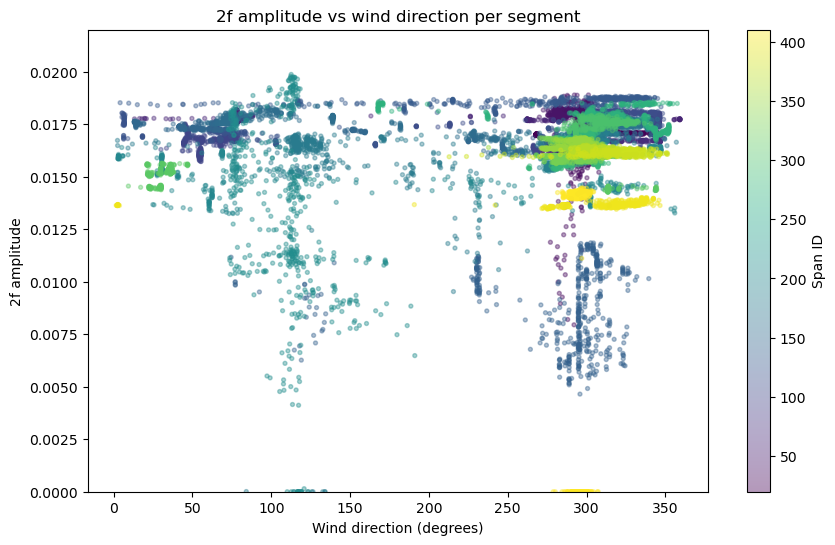

In [54]:
plt.figure(figsize=(10, 6))
plt.scatter(
    weather_df["winddir"],
    weather_df["amplitude"],
    c=weather_df["span_id"],
    alpha=0.4,
    s=8
)
plt.xlabel("Wind direction (degrees)")
plt.ylabel("2f amplitude")
plt.title("2f amplitude vs wind direction per segment")
plt.colorbar(label="Span ID")
plt.ylim(0,0.022)

(0.0, 0.022)

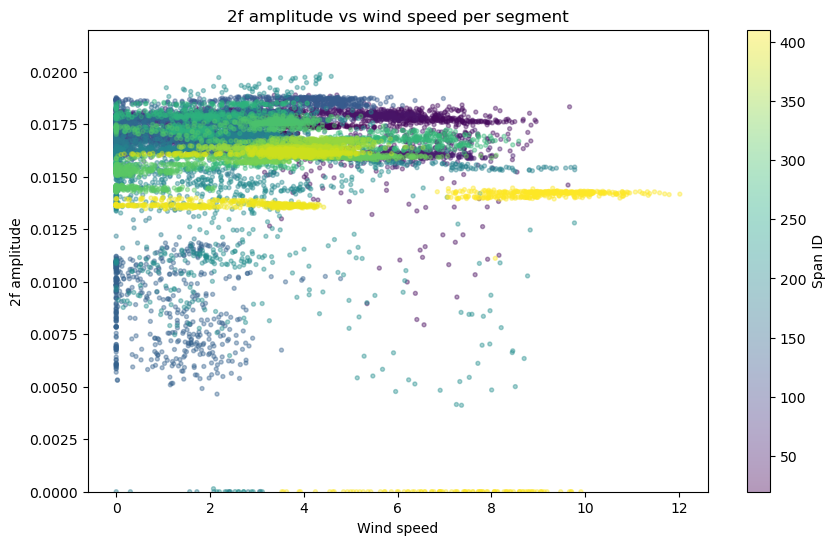

In [55]:
plt.figure(figsize=(10, 6))
plt.scatter(
    weather_df["windspeed"],
    weather_df["amplitude"],
    c=weather_df["span_id"],
    alpha=0.4,
    s=8
)
plt.xlabel("Wind speed")
plt.ylabel("2f amplitude")
plt.title("2f amplitude vs wind speed per segment")
plt.colorbar(label="Span ID")
plt.ylim(0,0.022)

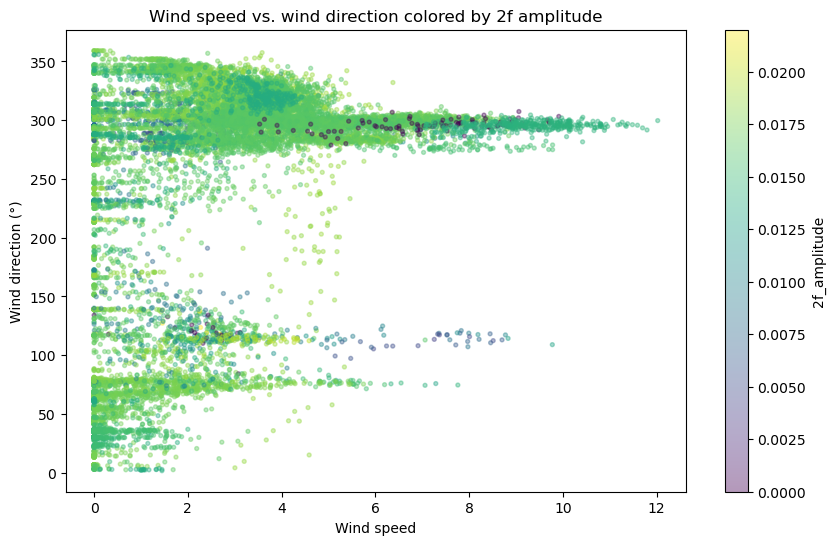

In [60]:
plt.figure(figsize=(10, 6))

plt.scatter(
    weather_df["windspeed"],
    weather_df["winddir"],
    c=weather_df["amplitude"],
    s=8,
    alpha=0.4,
    vmin = 0,
    vmax=0.022
)

plt.xlabel("Wind speed")
plt.ylabel("Wind direction (°)")
plt.title("Wind speed vs. wind direction colored by 2f amplitude")

plt.colorbar(label='2f_amplitude')


In [8]:
common_mode_set = full_common_modes[full_common_modes['span_id'] >= 270]
pre_relock = full_common_modes[full_common_modes['span_id'] < 180]

In [17]:
span_ids = common_mode_set['span_id'].unique()
print(span_ids)

[270 272 273 275 277 279 280 281 282 283 285 287 291 292 293 295 297 299
 300 301 302 303 305 307 309 310 311 312 313 315 317 319 320 321 322 323
 325 327 329 330 331 332 333 335 337 339 350 352 367 370 372 377 380 382
 387 400 402 410 412 417]


[16:59:30] WARNING [matplotlib.legend._parse_legend_args:1363] No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


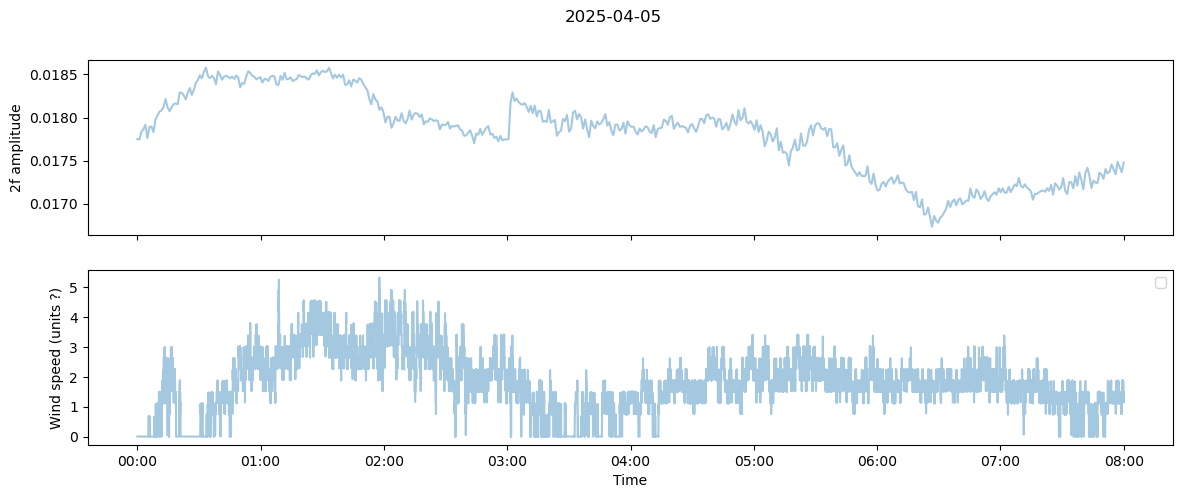

In [46]:
import matplotlib.dates as mdates
fig, ax = plt.subplots(2,1, figsize=(14, 5), sharex=True)
plt.suptitle("2025-04-05")
group = full_common_modes[full_common_modes['span_id']==270]
ax[0].plot(span_time, group['amplitude'], alpha=0.4)
ax[0].set_ylabel("2f amplitude")
# ax[0].set_title("Span 2f amplitude")

weather_time= pd.date_range(
    start="00:00",
    end="08:00",
    periods=len(filtered_data)
)
ax[1].plot(weather_time, filtered_data, alpha=0.4)
ax[1].set_ylabel("Wind speed (units ?)")
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
plt.xlabel("Time")
plt.legend()
#plt.ylim(0,0.03)


In [35]:
full_common_modes[full_common_modes['span_id']==270].head()

,amplitude,A,B,C,span_id,segment_id
10780,0.017750,0.002949,0.001765,-6.647625e-07,270,0
10781,0.017743,0.002946,0.001760,-3.004848e-10,270,1
10782,0.017834,0.002940,0.001744,-4.521671e-08,270,2
10783,0.017864,0.002947,0.001755,6.433100e-09,270,3
10784,0.017915,0.002942,0.001744,1.993541e-08,270,4


In [19]:
common_mode_set = common_mode_set.reset_index(drop=True)
print(common_mode_set.index.names)
print(common_mode_set.columns)

[None]
Index(['amplitude', 'A', 'B', 'C', 'span_id', 'segment_id'], dtype='object')


In [20]:
print(common_mode_set.head())

   amplitude         A         B             C  span_id  segment_id
0   0.017750  0.002949  0.001765 -6.647625e-07      270           0
1   0.017743  0.002946  0.001760 -3.004848e-10      270           1
2   0.017834  0.002940  0.001744 -4.521671e-08      270           2
3   0.017864  0.002947  0.001755  6.433100e-09      270           3
4   0.017915  0.002942  0.001744  1.993541e-08      270           4


## plots post relock spans (denser sampling)

Text(0.5, 1.0, 'post relock spans after 2025-04-04')

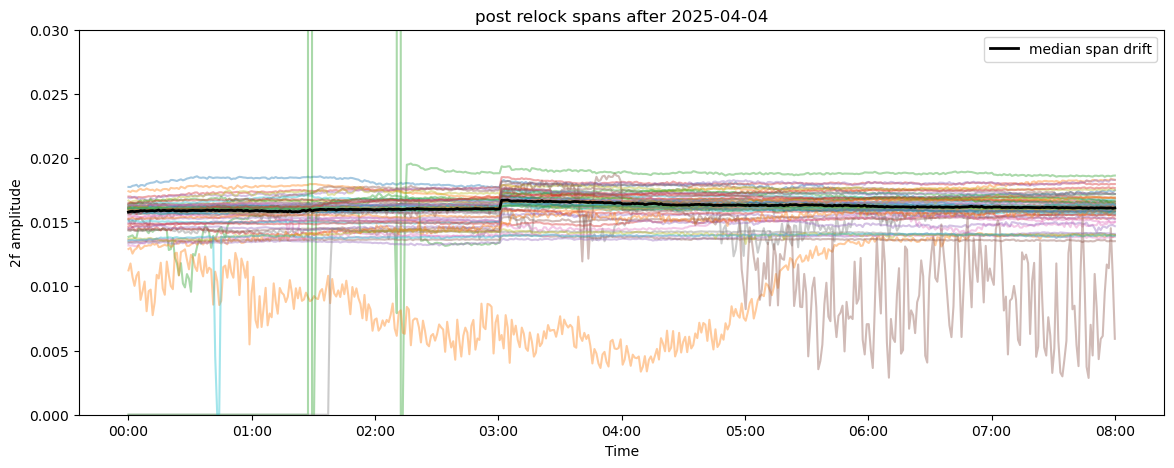

In [105]:
import matplotlib.dates as mdates
plt.figure(figsize=(14, 5))
for i in range(len(span_ids)):
    group = common_mode_set[common_mode_set['span_id']==span_ids[i]]
    plt.plot(span_time, group['amplitude'], alpha=0.4)
    #plt.plot(span_time, group['amplitude'], label=f"span {span_ids[i]}: {spans.iloc[span_ids[i]].start.strftime('%Y-%m-%d')}")
plt.ylabel("2f amplitude")
big_common_mode = common_mode_set.groupby('segment_id')[['amplitude', 'A', 'B', 'C']].median()
plt.plot(span_time, big_common_mode['amplitude'], linewidth=2,label='median span drift', color='black')

plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
plt.xlabel("Time")
plt.legend()
plt.ylim(0,0.03)
plt.title("post relock spans after 2025-04-04")

[17:05:26] WARNING [matplotlib.legend._parse_legend_args:1363] No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


(0.0, 0.03)

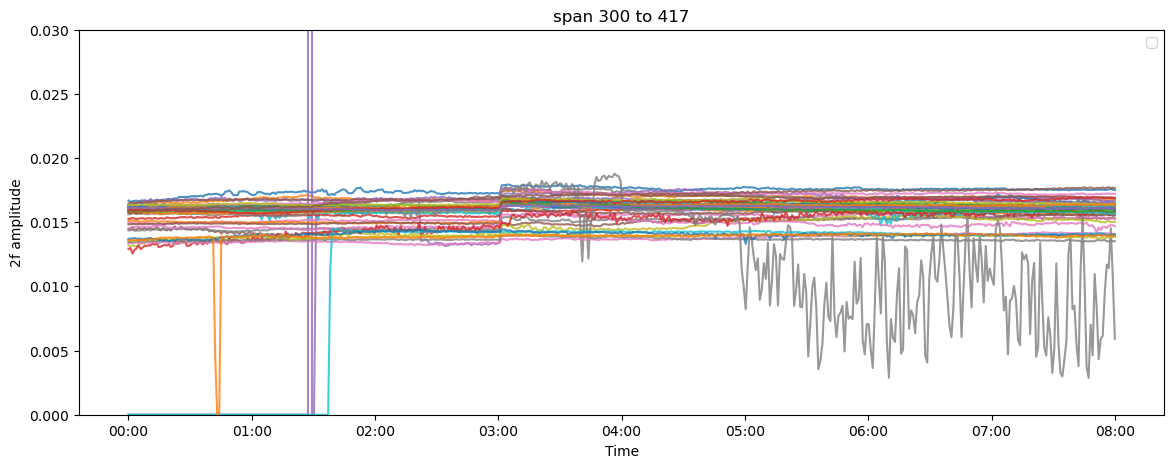

In [94]:
import matplotlib.dates as mdates
plt.figure(figsize=(14, 5))
for i in range(len(span_ids)):
    group = common_mode_set[common_mode_set['span_id']==span_ids[i]]
    plt.plot(span_time, group['amplitude'], alpha=0.8)
    #plt.plot(span_time, group['amplitude'], label=f"span {span_ids[i]}: {spans.iloc[span_ids[i]].start.strftime('%Y-%m-%d')}")
plt.ylabel("2f amplitude")
#big_common_mode = common_mode_set.groupby('segment_id')[['amplitude', 'A', 'B', 'C']].median()
#plt.plot(span_time, big_common_mode['amplitude'], linewidth=2,label='median span drift')

plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
plt.xlabel("Time")
plt.legend()
plt.title("span 300 to 417")
plt.ylim(0,0.03)

[17:03:55] WARNING [matplotlib.legend._parse_legend_args:1363] No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


Text(0.5, 1.0, 'span 350 to 417')

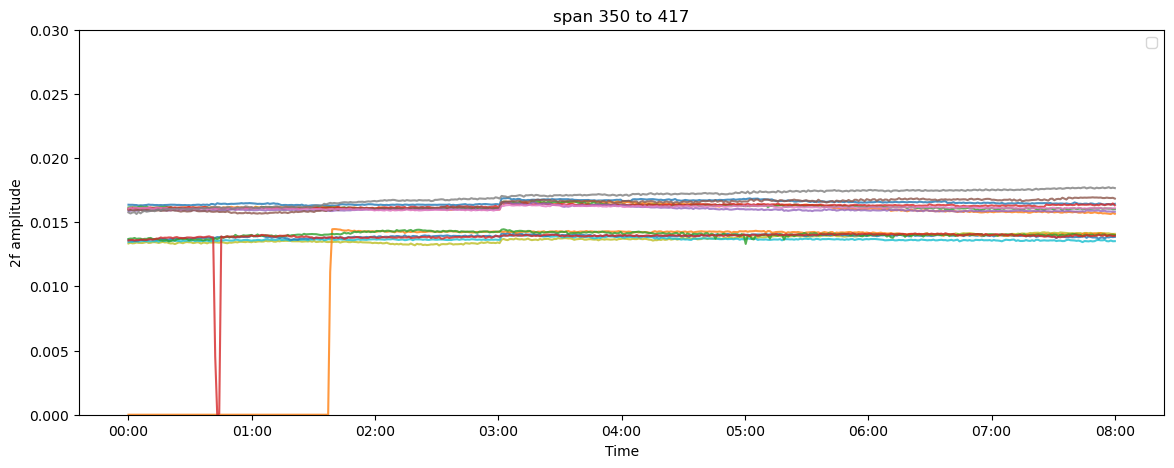

In [90]:
import matplotlib.dates as mdates
plt.figure(figsize=(14, 5))
for i in range(len(span_ids)):
    group = common_mode_set[common_mode_set['span_id']==span_ids[i]]
    plt.plot(span_time, group['amplitude'], alpha=0.8)
    #plt.plot(span_time, group['amplitude'], label=f"span {span_ids[i]}: {spans.iloc[span_ids[i]].start.strftime('%Y-%m-%d')}")
plt.ylabel("2f amplitude")
#big_common_mode = common_mode_set.groupby('segment_id')[['amplitude', 'A', 'B', 'C']].median()
#plt.plot(span_time, big_common_mode['amplitude'], linewidth=2,label='median span drift')

plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
plt.xlabel("Time")
plt.legend()
plt.ylim(0,0.03)
plt.title("span 350 to 417")

In [107]:
typical_spans = common_mode_set[
    common_mode_set.groupby("span_id")["amplitude"]
    .transform(lambda x: ((x >= 0.01) & (x <= 0.02)).all())
]
typical_spanid = typical_spans['span_id'].unique()

Text(0.5, 1.0, 'post relock spans after 2025-04-04, removing outliers')

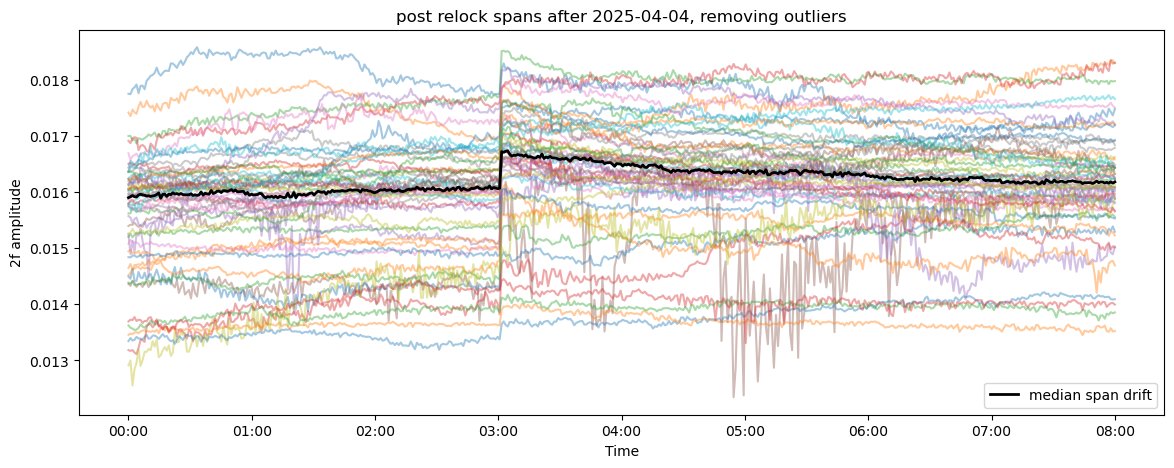

In [109]:
import matplotlib.dates as mdates
plt.figure(figsize=(14, 5))
for i in range(len(typical_spanid)):
    group = typical_spans[typical_spans['span_id']==typical_spanid[i]]
    plt.plot(span_time, group['amplitude'], alpha=0.4)
    #plt.plot(span_time, group['amplitude'], label=f"span {typical_spanid[i]}: {spans.iloc[typical_spanid[i]].start.strftime('%Y-%m-%d')}")
plt.ylabel("2f amplitude")
big_common_mode = typical_spans.groupby('segment_id')[['amplitude', 'A', 'B', 'C']].median()
plt.plot(span_time, big_common_mode['amplitude'], linewidth=2,label='median span drift', color='black')

plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
plt.xlabel("Time")
plt.legend()
plt.title("post relock spans after 2025-04-04, removing outliers")

Text(0.5, 1.0, 'pre relock spans BEFORE 2025-01-04, removing outliers')

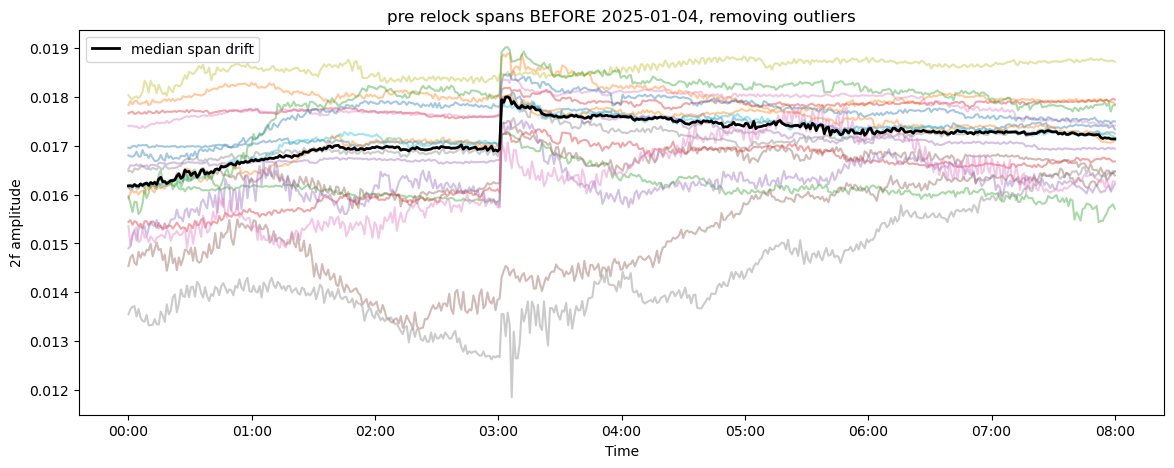

In [26]:
import matplotlib.dates as mdates
typical_spans_pre = pre_relock[
    pre_relock.groupby("span_id")["amplitude"]
    .transform(lambda x: ((x >= 0.01) & (x <= 0.02)).all())
]
typical_spanid_pre = typical_spans_pre['span_id'].unique()

plt.figure(figsize=(14, 5))
for i in range(len(typical_spanid_pre)):
    group = typical_spans_pre[typical_spans_pre['span_id']==typical_spanid_pre[i]]
    plt.plot(span_time, group['amplitude'], alpha=0.4)
    #plt.plot(span_time, group['amplitude'], label=f"span {typical_spanid[i]}: {spans.iloc[typical_spanid[i]].start.strftime('%Y-%m-%d')}")
plt.ylabel("2f amplitude")
big_common_mode = typical_spans_pre.groupby('segment_id')[['amplitude', 'A', 'B', 'C']].median()
plt.plot(span_time, big_common_mode['amplitude'], linewidth=2,label='median span drift', color='black')

plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
plt.xlabel("Time")
plt.legend()
plt.title("pre relock spans BEFORE 2025-01-04, removing outliers")

In [118]:
typical_spans_all = full_common_modes[
    full_common_modes.groupby("span_id")["amplitude"]
    .transform(lambda x: ((x >= 0.01) & (x <= 0.02)).all())
]
typical_spanid_all = typical_spans_all['span_id'].unique()

In [119]:
print(len(typical_spanid_all))
print(len(typical_spanid))

72
54


Text(0.5, 1.0, 'all spans, removing outliers')

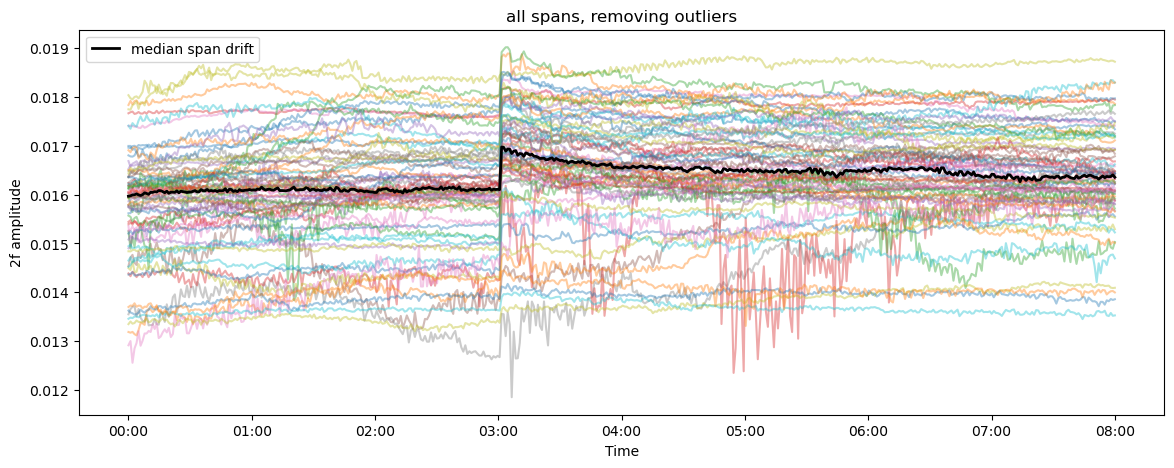

In [120]:
plt.figure(figsize=(14, 5))
for i in range(len(typical_spanid_all)):
    group = typical_spans_all[typical_spans_all['span_id']==typical_spanid_all[i]]
    plt.plot(span_time, group['amplitude'], alpha=0.4)
    #plt.plot(span_time, group['amplitude'], label=f"span {typical_spanid_all[i]}: {spans.iloc[typical_spanid_all[i]].start.strftime('%Y-%m-%d')}")
plt.ylabel("2f amplitude")
big_common_mode = typical_spans_all.groupby('segment_id')[['amplitude', 'A', 'B', 'C']].median()
plt.plot(span_time, big_common_mode['amplitude'], linewidth=2,label='median span drift', color='black')

plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
plt.xlabel("Time")
plt.legend()
plt.title("all spans, removing outliers")

[17:35:23] WARNING [matplotlib.legend._parse_legend_args:1363] No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


Text(0.5, 1.0, 'around relock time')

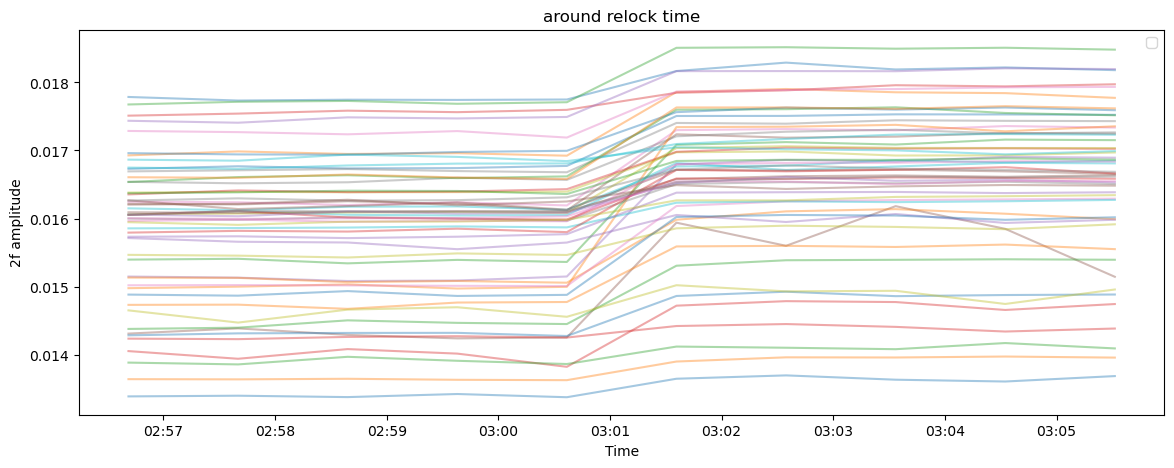

In [113]:
relock_time = typical_spans[(typical_spans['segment_id'] >= 180) & (typical_spans['segment_id'] < 190)]
plt.figure(figsize=(14, 5))
for i in range(len(typical_spanid)):
    group = relock_time[relock_time['span_id']==typical_spanid[i]]
    plt.plot(span_time[180:190], group['amplitude'], alpha=0.4)
    #plt.plot(span_time, group['amplitude'], label=f"span {typical_spanid[i]}: {spans.iloc[typical_spanid[i]].start.strftime('%Y-%m-%d')}")
plt.ylabel("2f amplitude")
# big_common_mode = typical_spans.groupby('segment_id')[['amplitude', 'A', 'B', 'C']].median()
# plt.plot(span_time, big_common_mode['amplitude'], linewidth=2,label='median span drift', color='black')

plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
plt.xlabel("Time")
plt.legend()
plt.title("around relock time")

## plots for every 10th span

In [ ]:
import matplotlib.dates as mdates
plt.figure(figsize=(14, 5))
for i in range(len(span_ids)):
    group = common_modes[common_modes['span_id']==span_ids[i]]
    plt.plot(span_time, group['amplitude'], alpha=0.8)
    #plt.plot(span_time, group['amplitude'], label=f"span {span_ids[i]}: {spans.iloc[span_ids[i]].start.strftime('%Y-%m-%d')}")
plt.ylabel("2f amplitude")
big_common_mode = common_modes.groupby('segment_id')[['amplitude', 'A', 'B', 'C']].median()
plt.plot(span_time, big_common_mode['amplitude'], linewidth=2,label='median span drift')

plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
plt.xlabel("Time")
plt.legend()

NameError: name 'common_modes' is not defined

<Figure size 1400x500 with 0 Axes>

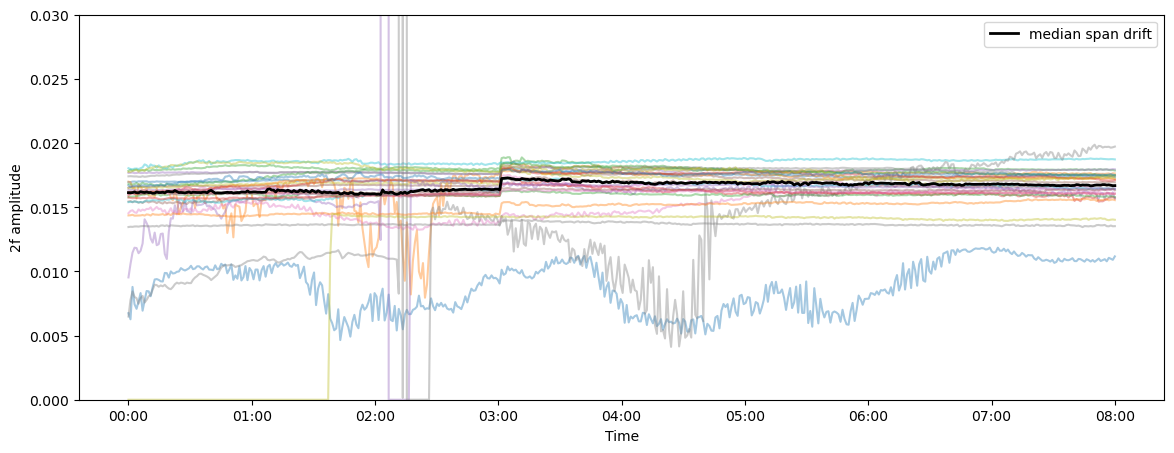

In [101]:
plt.figure(figsize=(14, 5))
for i in range(len(span_ids)):
    group = common_modes[common_modes['span_id']==span_ids[i]]
    plt.plot(span_time, group['amplitude'], alpha=0.4)
    #plt.plot(span_time, group['amplitude'], label=f"span {span_ids[i]}: {spans.iloc[span_ids[i]].start.strftime('%Y-%m-%d')}")
plt.ylabel("2f amplitude")
plt.plot(span_time, big_common_mode['amplitude'], linewidth=2,label='median span drift', color='black')

plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
plt.ylim(0,0.03)
plt.xlabel("Time")
plt.legend()

In [51]:
span_ids = common_modes['span_id'].unique()
print(span_ids)

[410]


In [43]:
print(common_mode["span_id"].unique())
print(common_modes["span_id"].unique())

[410]
[410]


Text(0.5, 0, 'Time')

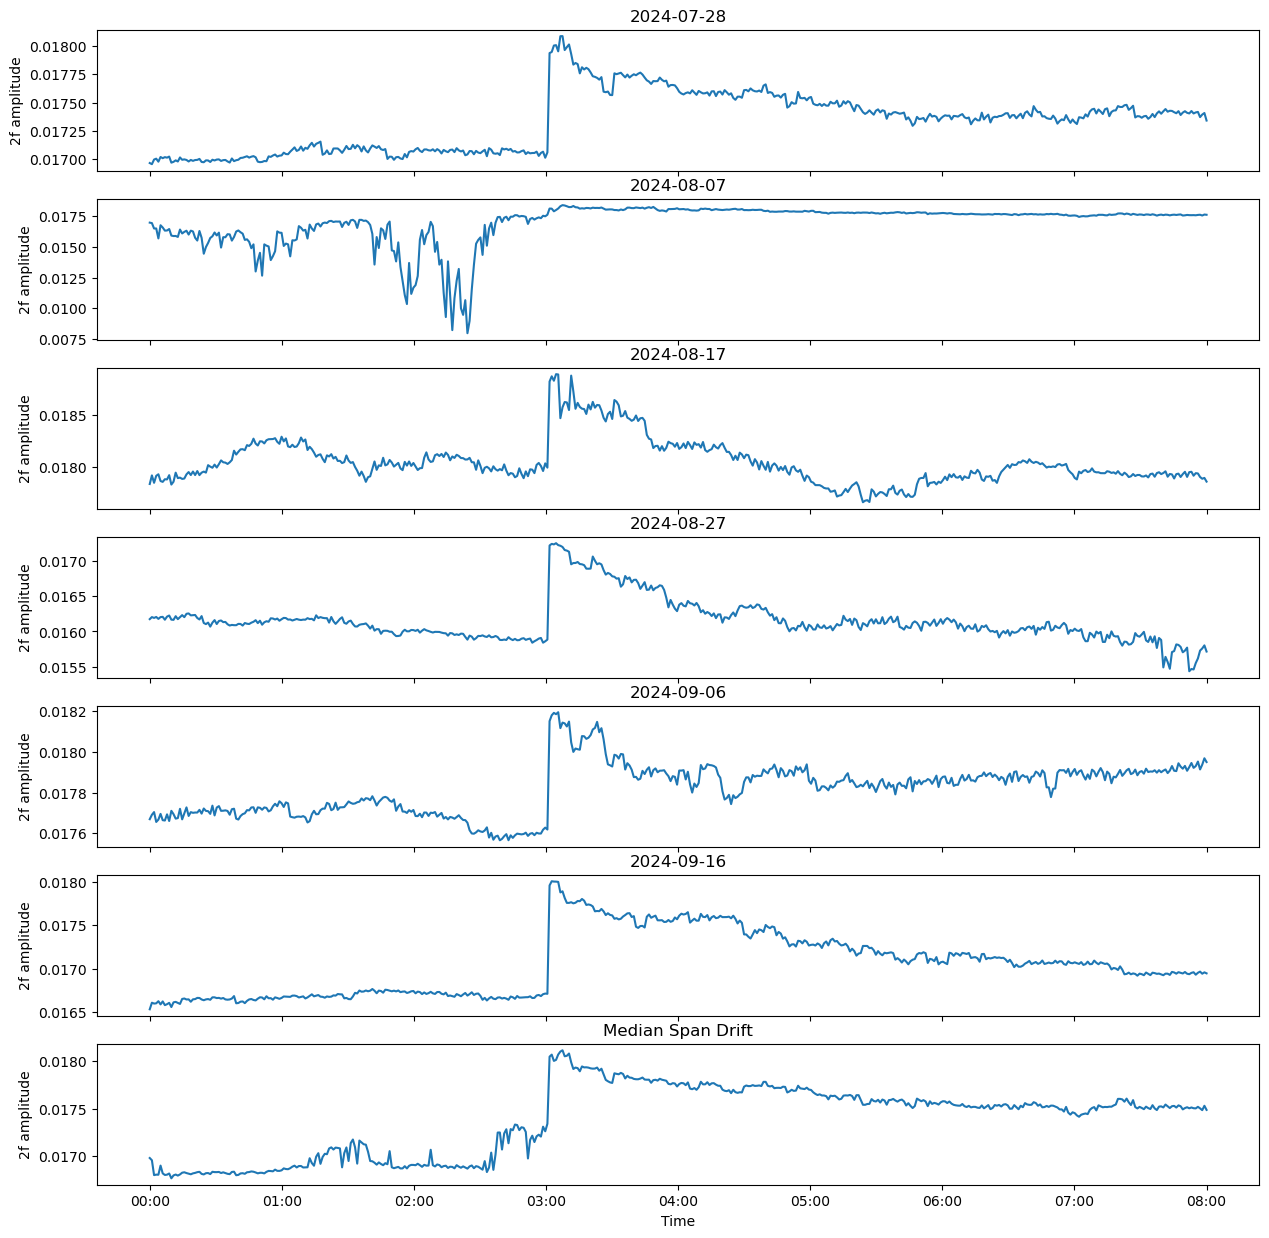

In [53]:
import matplotlib.dates as mdates
fig, ax = plt.subplots(7,1, figsize=(15, 15), sharex=True)
span_ids = common_modes['span_id'].unique()
for i in range(6):
    group = common_modes[common_modes['span_id']==span_ids[i]]
    ax[i].plot(span_time, group['amplitude'])
    ax[i].set_title(spans.iloc[span_ids[i]].start.strftime("%Y-%m-%d"))
    ax[i].set_ylabel("2f amplitude")
ax[6].plot(span_time, big_common_mode['amplitude'])
ax[6].set_title("Median Span Drift")
ax[6].set_ylabel("2f amplitude")

plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
plt.xlabel("Time")

Text(0.5, 0, 'Time')

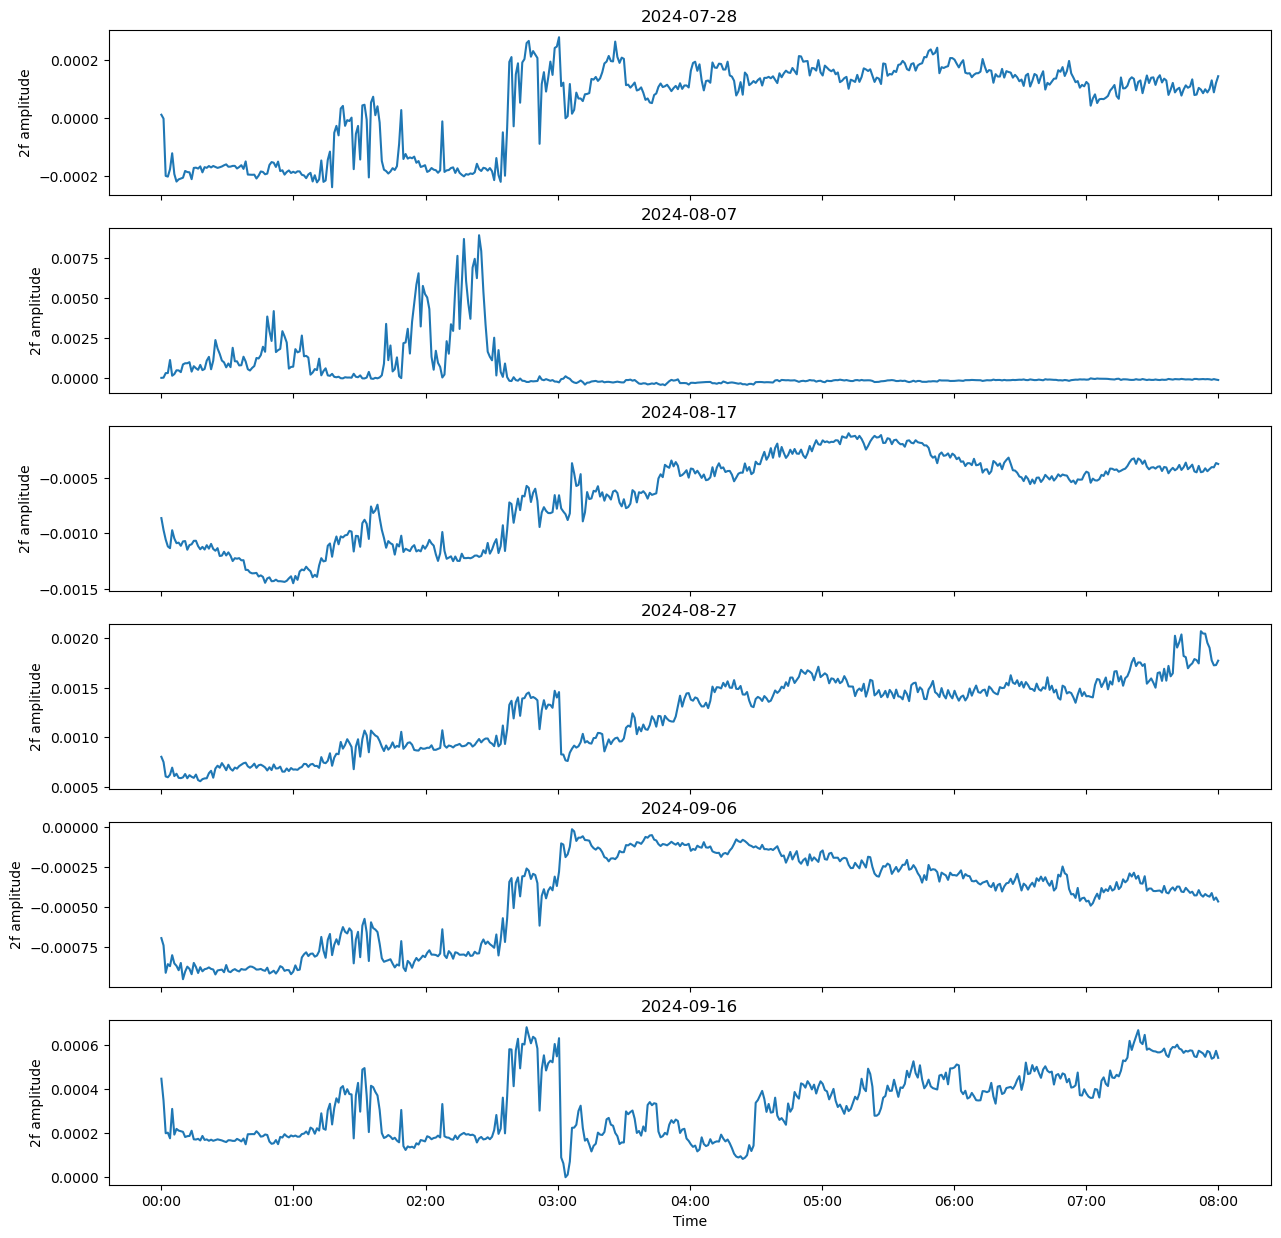

In [59]:
fig, ax = plt.subplots(6,1, figsize=(15, 15), sharex=True)
for i in range(6):
    group = common_modes[common_modes['span_id']==span_ids[i]]
    ax[i].plot(span_time, big_common_mode['amplitude'].to_numpy()-group['amplitude'].to_numpy())
    ax[i].set_title(spans.iloc[span_ids[i]].start.strftime("%Y-%m-%d"))
    ax[i].set_ylabel("2f amplitude")

plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
plt.xlabel("Time")

In [56]:
print(group['amplitude'].shape)

(490,)
